# CascadeGraph Demo: Linear-Nonlinear Models

This notebook is a Python port of `DemoMain.m`. It introduces basic functionality of CascadeGraph by implementing linear-nonlinear (LN) cascade models to predict a visual neuron's response to a white-noise light stimulus.

A simple LN model consists of a linear filter and a nonlinearity in series. The goal is to pick the filter and nonlinearity such that, given some stimulus, the model produces a good prediction of the neuron's response.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import cascadegraph as cg
%matplotlib inline

## Settings

In [2]:
FREQUENCY_CUTOFF = 20       # Hz
FILTER_PTS = 1250           # length of one side of filter
CORRECT_STIM_POWER = True
USE_ANTICAUSAL = False

NUM_BINS = 100
BINNING_TYPE = "equalN"
POLYFIT_DEGREE = 3

## Load and explore data

Load the example data containing electrical responses recorded in a visual neuron while a noisy light stimulus was presented.

In [3]:
# Load data
data = loadmat("../exampleData.mat")

stimulus = np.array(data["stimulus"], dtype=float)
response = np.array(data["response"], dtype=float)
sampling_interval = float(data["samplingInterval"].squeeze())

print(f"stimulus shape:      {stimulus.shape}")
print(f"response shape:      {response.shape}")
print(f"sampling interval:   {sampling_interval} s")
print(f"sample rate:         {1/sampling_interval:.0f} Hz")
print(f"trial duration:      {stimulus.shape[1] * sampling_interval:.2f} s")
print(f"number of trials:    {stimulus.shape[0]}")

stimulus shape:      (20, 5000)
response shape:      (20, 5000)
sampling interval:   0.001 s
sample rate:         1000 Hz
trial duration:      5.00 s
number of trials:    20


In [4]:
# Examine the raw data
print("Stimulus statistics:")
print(f"  mean:  {stimulus.mean():.4f}")
print(f"  std:   {stimulus.std():.4f}")
print(f"  min:   {stimulus.min():.4f}")
print(f"  max:   {stimulus.max():.4f}")

print("\nResponse statistics:")
print(f"  mean:  {response.mean():.4f}")
print(f"  std:   {response.std():.4f}")
print(f"  min:   {response.min():.4f}")
print(f"  max:   {response.max():.4f}")

Stimulus statistics:
  mean:  0.9885
  std:   0.9944
  min:   -2.7044
  max:   4.9395

Response statistics:
  mean:  -63.3193
  std:   191.9862
  min:   -1798.1351
  max:   286.6155


In [5]:
# Filter out high-frequency noise and split into train/test
response = cg.apply_frequency_cutoff(response, FREQUENCY_CUTOFF, sampling_interval)

# 80/20 split: 16 training trials, 4 test trials
stimulus_train = stimulus[:16, :]
response_train = response[:16, :]
stimulus_test = stimulus[16:20, :]
response_test = response[16:20, :]

t_trial = np.arange(1, stimulus.shape[1] + 1) * sampling_interval

print(f"Training set: {stimulus_train.shape}")
print(f"Test set:     {stimulus_test.shape}")

Training set: (16, 5000)
Test set:     (4, 5000)


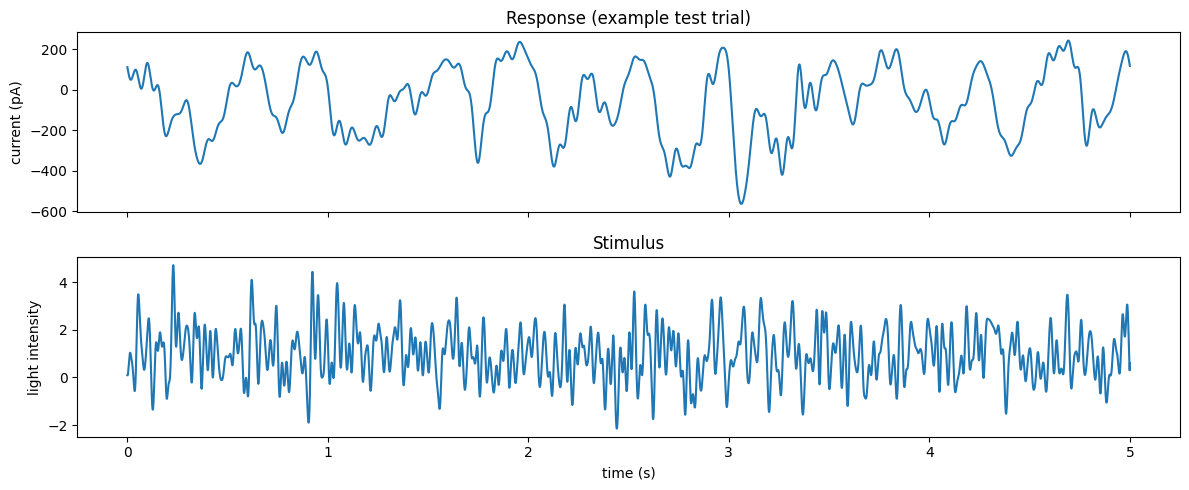

In [6]:
# Visualize example trial
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t_trial, response_test[0, :])
axes[0].set_ylabel("current (pA)")
axes[0].set_title("Response (example test trial)")
axes[1].plot(t_trial, stimulus_test[0, :])
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("light intensity")
axes[1].set_title("Stimulus")
plt.tight_layout()
plt.show()

## Compute filter

Because the stimulus is Gaussian white noise, the best linear filter can be computed using cross-correlation between stimulus and response.

In [7]:
filter_causal, filter_anticausal = cg.compute_filter(
    stimulus_train, response_train, FILTER_PTS,
    correct_stim_power=CORRECT_STIM_POWER,
    frequency_cutoff=FREQUENCY_CUTOFF,
    sampling_interval=sampling_interval,
)

if USE_ANTICAUSAL:
    filt = np.concatenate([filter_causal, filter_anticausal])
else:
    filt = filter_causal

# Normalize filter
filt = filt / np.max(np.abs(filt))

t_filter = np.arange(1, len(filt) + 1) * sampling_interval

print(f"Filter length: {len(filt)} points ({len(filt) * sampling_interval:.4f} s)")

Filter length: 1250 points (1.2500 s)


## Model prediction (without computation graph)

First, let's build the LN model directly without the graph representation.

In [8]:
# Filter stimulus and sample nonlinearity on training data
generator_signal = cg.convolve_filter_with_stim(filt, stimulus_train, USE_ANTICAUSAL)
nl_x, nl_y = cg.sample_nl(generator_signal, response_train, NUM_BINS, BINNING_TYPE)

# Fit polynomial nonlinearity (with centering/scaling like MATLAB polyfit with mu)
mu_center, mu_scale = np.mean(nl_x), np.std(nl_x)
nl_x_scaled = (nl_x - mu_center) / mu_scale
polyfit_coeff = np.polyfit(nl_x_scaled, nl_y, POLYFIT_DEGREE)

# Compute prediction on test data
generator_signal_test = cg.convolve_filter_with_stim(filt, stimulus_test, USE_ANTICAUSAL)
prediction = np.polyval(polyfit_coeff, (generator_signal_test - mu_center) / mu_scale)

# Evaluate performance
r2 = cg.compute_variance_explained(prediction, response_test)
r2_all = cg.compute_variance_explained(prediction.ravel(), response_test.ravel())
print(f"Overall R^2: {r2_all:.4f}   Mean R^2: {np.mean(r2):.4f}")

Overall R^2: 0.7260   Mean R^2: 0.6955


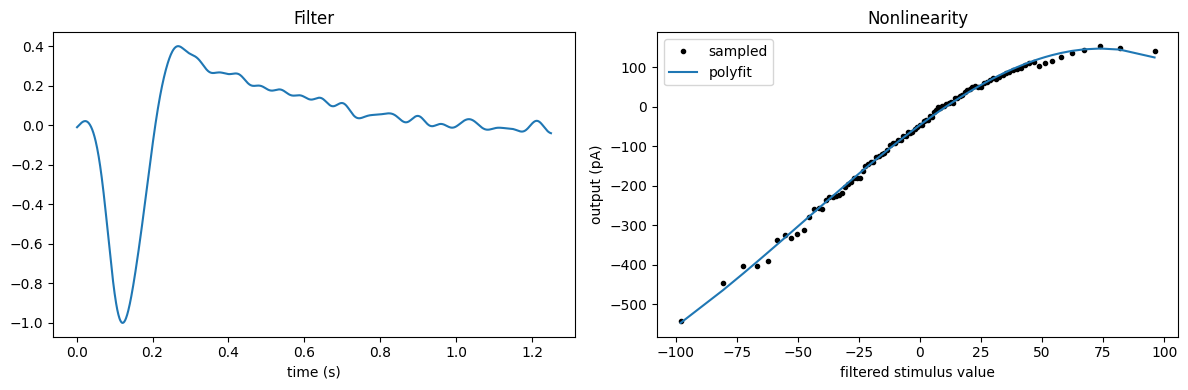

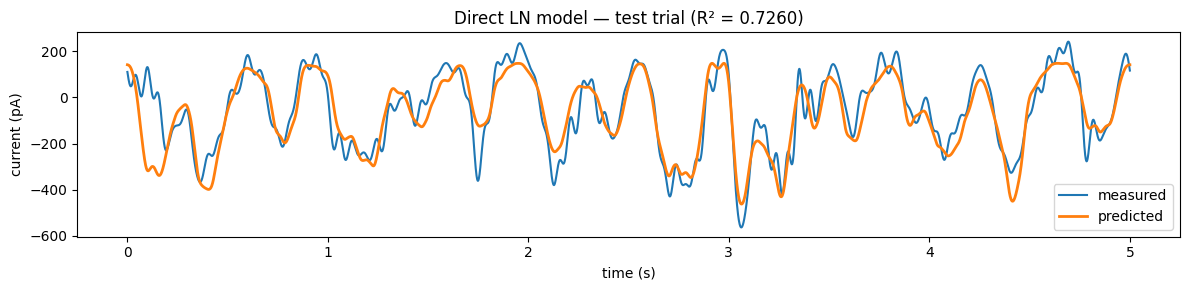

In [9]:
# Plot filter and nonlinearity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_filter, filt)
axes[0].set_xlabel("time (s)")
axes[0].set_title("Filter")

axes[1].plot(nl_x, nl_y, "ko", markersize=3, label="sampled")
axes[1].plot(nl_x, np.polyval(polyfit_coeff, nl_x_scaled), label="polyfit")
axes[1].set_xlabel("filtered stimulus value")
axes[1].set_ylabel("output (pA)")
axes[1].set_title("Nonlinearity")
axes[1].legend()
plt.tight_layout()
plt.show()

# Plot prediction vs actual
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_trial, response_test[0, :], label="measured")
ax.plot(t_trial, prediction[0, :], linewidth=2, label="predicted")
ax.set_xlabel("time (s)")
ax.set_ylabel("current (pA)")
ax.set_title(f"Direct LN model — test trial (R² = {r2_all:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## Model prediction (with computation graph)

Now let's do the same thing using CascadeGraph node objects. We create nodes for the stimulus, filter, and nonlinearity, connect them, and run the graph.

We compare polynomial and sigmoid nonlinearities.

In [10]:
# Filter stimulus and sample nonlinearity (same as before)
generator_signal = cg.convolve_filter_with_stim(filt, stimulus_train, USE_ANTICAUSAL)
nl_x, nl_y = cg.sample_nl(generator_signal, response_train, NUM_BINS, BINNING_TYPE)

# Instantiate nodes
data_node = cg.DataNode(stimulus_test)
filter_node = cg.FilterNode(filt, USE_ANTICAUSAL)
polyfit_nl_node = cg.PolyfitNlNode()

# Fit nonlinearity
polyfit_nl_node.fit_to_sample(nl_x, nl_y, POLYFIT_DEGREE)

# Connect graph: DataNode -> FilterNode -> PolyfitNlNode
filter_node.upstream.append(data_node)
polyfit_nl_node.upstream.append(filter_node)

# Run model
prediction_poly = polyfit_nl_node.process_upstream()

r2_poly = cg.compute_variance_explained(prediction_poly.ravel(), response_test.ravel())
print(f"PolyFit graph — Overall R²: {r2_poly:.4f}")

PolyFit graph — Overall R²: 0.7260


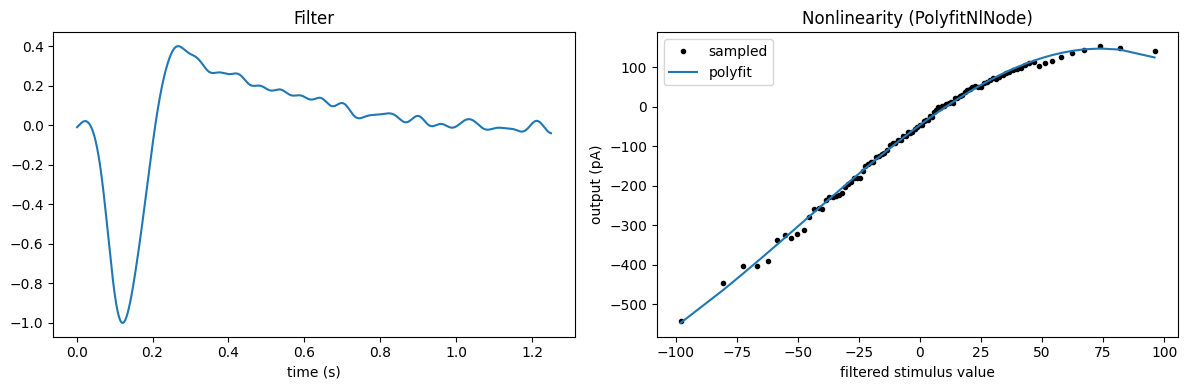

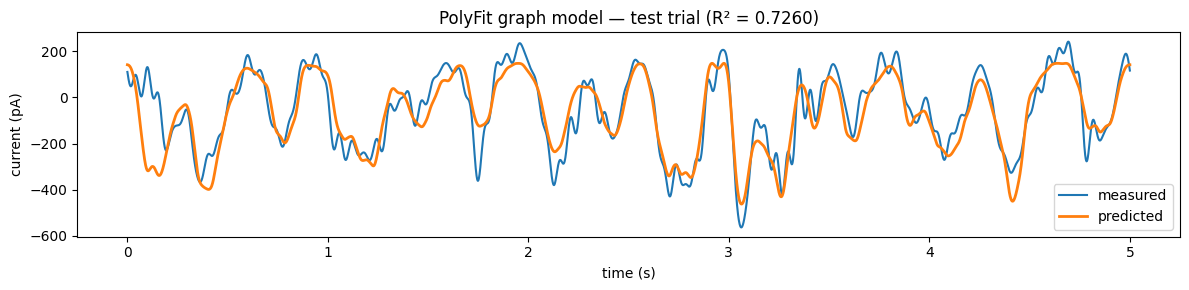

In [11]:
# Plot graph-based polyfit model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_filter, filter_node.filter)
axes[0].set_xlabel("time (s)")
axes[0].set_title("Filter")

axes[1].plot(nl_x, nl_y, "ko", markersize=3, label="sampled")
axes[1].plot(nl_x, polyfit_nl_node.process(nl_x), label="polyfit")
axes[1].set_xlabel("filtered stimulus value")
axes[1].set_ylabel("output (pA)")
axes[1].set_title("Nonlinearity (PolyfitNlNode)")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_trial, response_test[0, :], label="measured")
ax.plot(t_trial, prediction_poly[0, :], linewidth=2, label="predicted")
ax.set_xlabel("time (s)")
ax.set_ylabel("current (pA)")
ax.set_title(f"PolyFit graph model — test trial (R² = {r2_poly:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

### Sigmoid nonlinearity

Reuse the existing stimulus and filter nodes, just add a new sigmoid nonlinearity node.

In [12]:
sigmoid_nl_node = cg.SigmoidNlNode()
sigmoid_nl_node.fit_to_sample(nl_x, nl_y)
sigmoid_nl_node.upstream.append(filter_node)

prediction_sig = sigmoid_nl_node.process_upstream()

r2_sig = cg.compute_variance_explained(prediction_sig.ravel(), response_test.ravel())
print(f"Sigmoid graph — Overall R²: {r2_sig:.4f}")

Sigmoid graph — Overall R²: 0.7307


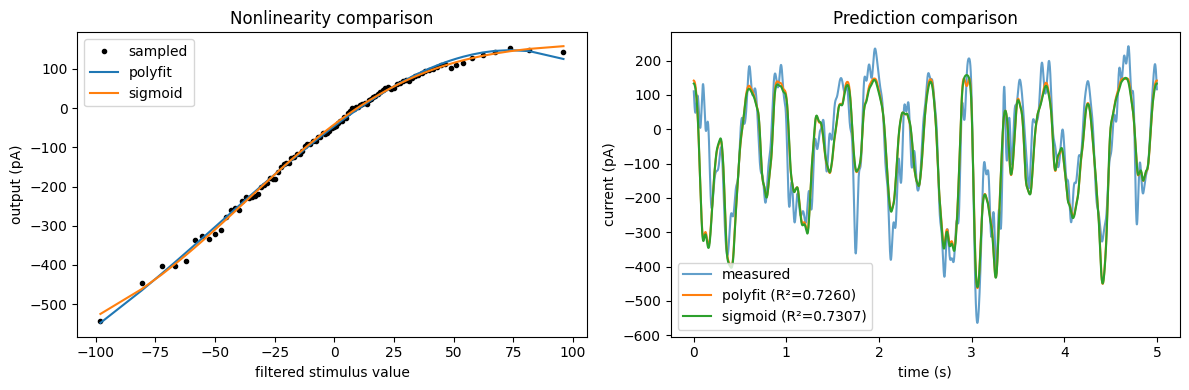

In [13]:
# Compare polyfit vs sigmoid nonlinearities
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(nl_x, nl_y, "ko", markersize=3, label="sampled")
axes[0].plot(nl_x, polyfit_nl_node.process(nl_x), label="polyfit")
axes[0].plot(nl_x, sigmoid_nl_node.process(nl_x), label="sigmoid")
axes[0].set_xlabel("filtered stimulus value")
axes[0].set_ylabel("output (pA)")
axes[0].set_title("Nonlinearity comparison")
axes[0].legend()

axes[1].plot(t_trial, response_test[0, :], label="measured", alpha=0.7)
axes[1].plot(t_trial, prediction_poly[0, :], linewidth=1.5, label=f"polyfit (R²={r2_poly:.4f})")
axes[1].plot(t_trial, prediction_sig[0, :], linewidth=1.5, label=f"sigmoid (R²={r2_sig:.4f})")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("current (pA)")
axes[1].set_title("Prediction comparison")
axes[1].legend()
plt.tight_layout()
plt.show()

## Jointly fit parameterized filter and nonlinearity (LnHyperNode)

Instead of computing the filter by cross-correlation and fitting the nonlinearity separately, we can jointly optimize a parameterized filter and sigmoid nonlinearity using `LnHyperNode`. This optimizes all 9 parameters together.

In [14]:
stim_node = cg.DataNode(stimulus_train)
model = cg.LnHyperNode()
model.upstream.append(stim_node)
model.dt_stored = sampling_interval

# Initial conditions: [numFilt, tauR, tauD, tauP, phi, alpha, beta, gamma, epsilon]
p0 = np.array([5, 3, 0.1, 11, 800, 800, 0.001, 0.001, -600], dtype=float)

# Optimize (5 iterations)
for i in range(5):
    model.optimize_params(p0, stimulus_train, response_train, dt=sampling_interval)
    p0 = model.get_free_params()
    
    prediction = model.process_upstream()
    r2 = cg.compute_variance_explained(prediction.ravel(), response_train.ravel())
    print(f"  Training iter {i+1} R²: {r2:.4f}")

  Training iter 1 R²: 0.3706
  Training iter 2 R²: 0.7004
  Training iter 3 R²: 0.7389
  Training iter 4 R²: 0.7401
  Training iter 5 R²: 0.7401


LnHyperNode test R²: 0.6812


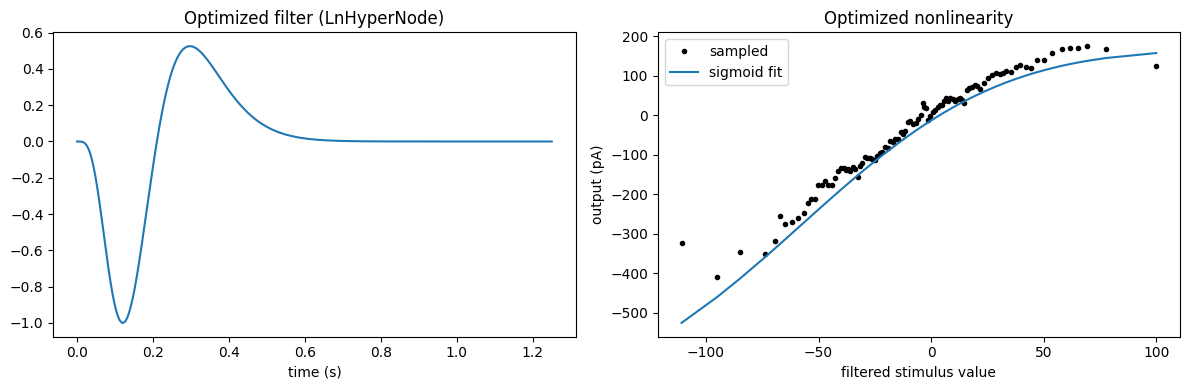

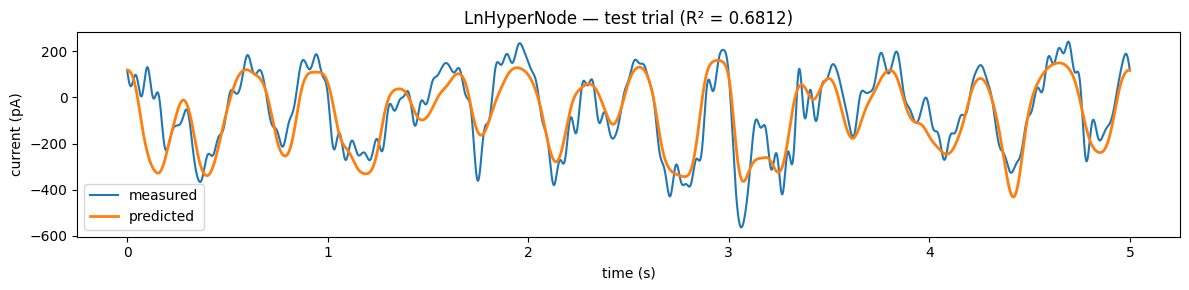

In [15]:
# Evaluate on test set
stim_node.data = stimulus_test
prediction = model.process_upstream()

r2_ln = cg.compute_variance_explained(prediction.ravel(), response_test.ravel())
print(f"LnHyperNode test R²: {r2_ln:.4f}")

# Visualize optimized filter and nonlinearity
sub = model.subnodes()
opt_filter = sub["filter"].get_filter(FILTER_PTS, sampling_interval)

generator_signal_test = sub["filter"].process(stimulus_test, sampling_interval)
nl_x_opt, nl_y_opt = cg.sample_nl(generator_signal_test, response_test, NUM_BINS, BINNING_TYPE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_filter, opt_filter)
axes[0].set_xlabel("time (s)")
axes[0].set_title("Optimized filter (LnHyperNode)")

axes[1].plot(nl_x_opt, nl_y_opt, "ko", markersize=3, label="sampled")
axes[1].plot(nl_x_opt, sub["nonlinearity"].process(nl_x_opt), label="sigmoid fit")
axes[1].set_xlabel("filtered stimulus value")
axes[1].set_ylabel("output (pA)")
axes[1].set_title("Optimized nonlinearity")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_trial, response_test[0, :], label="measured")
ax.plot(t_trial, prediction[0, :], linewidth=2, label="predicted")
ax.set_xlabel("time (s)")
ax.set_ylabel("current (pA)")
ax.set_title(f"LnHyperNode — test trial (R² = {r2_ln:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## Two-arm branching model (TwoArmLnHyperNode)

A model with two parallel filter pathways: one feeds directly into a sum, the other passes through its own nonlinearity first. The sum then feeds into a final nonlinearity. This allows modeling separate neural mechanisms.

In [16]:
stim_node2 = cg.DataNode(stimulus_train)
model2 = cg.TwoArmLnHyperNode()
model2.upstream.append(stim_node2)
model2.dt_stored = sampling_interval

# Initial conditions (18 params):
# filter1(5), filter2(5), nl1(4), nl2(4)
p0 = np.array([
    5, 3, 0.1, 11, 800,    # filter1
    5, 3, 0.1, 11, 800,    # filter2
    800, 0.001, 0.001, -600,  # nl1
    800, 0.001, 0.001, -600,  # nl2
], dtype=float)

# Optimize (5 iterations)
for i in range(5):
    model2.optimize_params(p0, stimulus_train, response_train, dt=sampling_interval)
    p0 = model2.get_free_params()
    
    prediction2 = model2.process_upstream()
    r2 = cg.compute_variance_explained(prediction2.ravel(), response_train.ravel())
    print(f"  Training iter {i+1} R²: {r2:.4f}")

  Training iter 1 R²: 0.4213
  Training iter 2 R²: 0.7023
  Training iter 3 R²: 0.7836
  Training iter 4 R²: 0.7879
  Training iter 5 R²: 0.7891


TwoArmLnHyperNode test R²: 0.7237


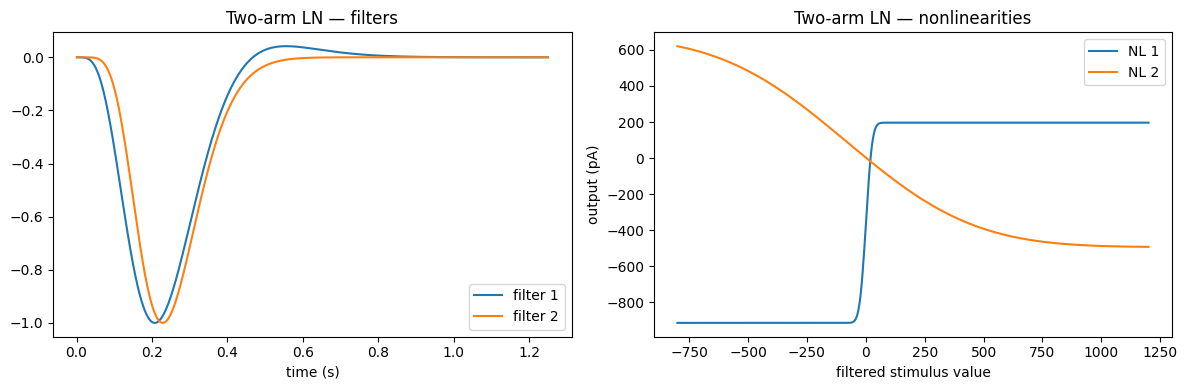

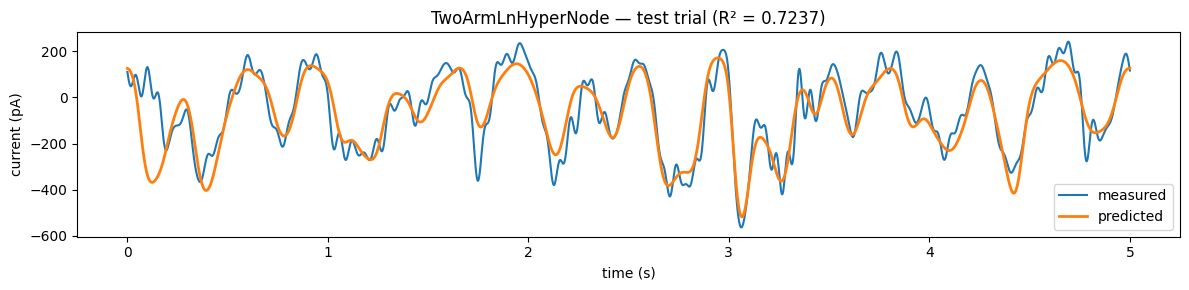

In [17]:
# Evaluate on test set
stim_node2.data = stimulus_test
prediction2 = model2.process_upstream()

r2_two_arm = cg.compute_variance_explained(prediction2.ravel(), response_test.ravel())
print(f"TwoArmLnHyperNode test R²: {r2_two_arm:.4f}")

# Visualize
sub2 = model2.subnodes()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_filter, sub2["filter1"].get_filter(FILTER_PTS, sampling_interval), label="filter 1")
axes[0].plot(t_filter, sub2["filter2"].get_filter(FILTER_PTS, sampling_interval), label="filter 2")
axes[0].set_xlabel("time (s)")
axes[0].set_title("Two-arm LN — filters")
axes[0].legend()

x_range = np.linspace(-800, 1200, 500)
axes[1].plot(x_range, sub2["nonlinearity1"].process(x_range), label="NL 1")
axes[1].plot(x_range, sub2["nonlinearity2"].process(x_range), label="NL 2")
axes[1].set_xlabel("filtered stimulus value")
axes[1].set_ylabel("output (pA)")
axes[1].set_title("Two-arm LN — nonlinearities")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_trial, response_test[0, :], label="measured")
ax.plot(t_trial, prediction2[0, :], linewidth=2, label="predicted")
ax.set_xlabel("time (s)")
ax.set_ylabel("current (pA)")
ax.set_title(f"TwoArmLnHyperNode — test trial (R² = {r2_two_arm:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Model | Test R² |
|-------|---------|
| Direct LN (polyfit, no graph) | see above |
| Graph LN (PolyfitNlNode) | see above |
| Graph LN (SigmoidNlNode) | see above |
| LnHyperNode (joint optimization) | see above |
| TwoArmLnHyperNode (branching) | see above |

Try experimenting with more complicated models! Each node can have multiple parents and children, so you can build larger graphs with more complex structure.